<h1 style="background: linear-gradient(to right, #ff6b6b, #4ecdc4); 
           color: white; 
           padding: 20px; 
           border-radius: 10px; 
           text-align: center; 
           font-family: Arial, sans-serif; 
           text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">
  LoRA and QLoRA
</h1>

In this notebook we will learn about LoRA and QLoRA: how to make the trainable part of a model small, first by building a LoRA layer from scratch in plain PyTorch, then by combining it with quantization from [`01_quantization.ipynb`](01_quantization.ipynb) to run a real QLoRA fine tune with `transformers`, `peft`, and `bitsandbytes`.

This is the second of two notebooks that build fine tuning up from first principles. Once you know what is actually happening at this level, you are in a good position to judge when a fully managed service is worth using instead of running this stack yourself.

By the end of this notebook you will:

1. Understand why fine tuning every parameter of a large model is expensive,
2. Implement a LoRA linear layer from scratch in plain PyTorch, and apply it to a real pretrained model,
3. Confirm numerically that a trained adapter really is low rank,
4. Combine your from scratch understanding with `peft` and `bitsandbytes` to fine tune a quantized model end to end, then merge the result.

<div align="center"><img src="assets/lora_decomposition.svg" alt="A frozen weight matrix W0 plus a low rank update B times A, merged into W prime" width="750"/></div>

<h1 style="background: linear-gradient(to right, #ff6b6b, #4ecdc4); 
           color: white; 
           padding: 20px; 
           border-radius: 10px; 
           text-align: center; 
           font-family: Arial, sans-serif; 
           text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">
  LoRA from Scratch
</h1>

No `peft`, no `bitsandbytes`, just plain PyTorch. Building the mechanism by hand first, and applying it to a real model, is what makes the library calls in the second half of this notebook feel obvious instead of magical.

## `Step 1`: Why not just fine tune everything

Full fine tuning updates every weight in the model, and training costs more memory than the weights alone. With the [Adam optimizer](https://arxiv.org/abs/1412.6980), a very common choice, every trainable parameter needs its own gradient plus two optimizer moment buffers (momentum and variance), on top of the weight itself. So roughly four times the trainable parameter count in extra memory, before even accounting for activations. Fully fine tuning a 7 billion parameter model in FP16 with Adam, for example, needs on the order of 100 GB once gradients and optimizer state are included, far more than the roughly 14 GB the weights themselves take up.

There is also a storage problem. Fine tune the same base model for ten different tasks the naive way and you end up with ten full copies of the model, one of which might be 90 percent identical to the others.

Parameter efficient fine tuning (PEFT) methods solve both problems by freezing nearly all of the base model and training a small number of extra parameters that steer it. LoRA is the most widely adopted PEFT method today. Other approaches in the same family include prefix tuning and adapter layers, see the [Hugging Face PEFT documentation](https://huggingface.co/docs/peft/main/en/index) for a broader survey.

## `Step 2`: The LoRA idea

Matrix multiplication has a convenient property: multiplying a $(d, r)$ matrix by an $(r, k)$ matrix produces a full $(d, k)$ matrix, using only $r(d + k)$ numbers instead of the $dk$ the full matrix would need. The resulting matrix is not arbitrary, though: it cannot have a rank higher than $r$, the shared, "facing" dimension of the two small matrices. A matrix's rank is how many of its rows or columns are truly independent, so a low rank matrix, however large it looks, is really just $r$ independent directions dressed up in a $d$ by $k$ shape.

[Aghajanyan et al., 2020](https://arxiv.org/abs/2012.13255) observed that pretrained language models have a surprisingly low intrinsic dimension when adapting to a new task: even though the full weight matrix is huge, the update needed to specialize it lives in a small subspace. [Hu et al., 2021, "LoRA: Low-Rank Adaptation of Large Language Models"](https://arxiv.org/abs/2106.09685) turned that observation into a practical training recipe, using exactly the low rank matrix product above as the update itself.

Freeze the pretrained weight matrix $W_0 \in \mathbb{R}^{d \times k}$. Instead of learning a full update $\Delta W$, which would also be $d \times k$, learn it as the product of two much smaller matrices:

$$
\Delta W = BA, \qquad B \in \mathbb{R}^{d \times r}, \quad A \in \mathbb{R}^{r \times k}, \quad r \ll \min(d, k)
$$

The layer's forward pass becomes:

$$
h = W_0 x + \frac{\alpha}{r} (BA) x
$$

$r$, the rank, is the one knob that controls how much capacity the adapter has. $\alpha$ is a scaling factor, conventionally set to twice the rank ($\alpha = 2r$), that keeps the update's effective magnitude in a sensible range regardless of $r$, so changing the rank does not force you to retune the learning rate.

$A$ is initialized with small random values and $B$ is initialized to exactly zero, so $BA = 0$ on the very first forward pass and the layer produces exactly the same output as the frozen base model:

$$
h = W_0 x + \frac{\alpha}{r}(0)x = W_0 x
$$

Training then nudges $A$ and $B$ away from that starting point, and only ever touches those two small matrices, $r(d+k)$ trainable numbers instead of $dk$.

LoRA adapters are typically added to the attention projections in every transformer block (and sometimes the MLP layers too). More target modules, or a higher rank, means more trainable parameters and usually a better fit to the new task, at the cost of some of the efficiency you were after in the first place.

## `Step 3`: Implementing a LoRA layer from scratch

The class below wraps an existing `nn.Linear`, freezes it, and adds the two small trainable matrices `lora_A` and `lora_B` described above.

In [1]:
import torch
import torch.nn as nn

class LoRALinear(nn.Module):
    def __init__(self, base_linear, rank=4, alpha=8):
        super().__init__()
        self.base = base_linear
        self.base.weight.requires_grad_(False)
        if self.base.bias is not None:
            self.base.bias.requires_grad_(False)

        in_features = base_linear.in_features
        out_features = base_linear.out_features
        self.scaling = alpha / rank

        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

    def forward(self, x):
        base_out = self.base(x)
        lora_out = (x @ self.lora_A.T) @ self.lora_B.T
        return base_out + self.scaling * lora_out

`lora_A` has shape `(rank, in_features)` and `lora_B` has shape `(out_features, rank)`, matching `A` and `B` from step 2. `base_linear`'s weight and bias are frozen with `requires_grad_(False)`, so an optimizer that only receives `lora_A` and `lora_B` never touches the original weights.

Now wrap a linear layer and compare how many parameters are trainable versus how many exist in total.

In [2]:
base_layer = nn.Linear(768, 768)
lora_layer = LoRALinear(base_layer, rank=8, alpha=16)

total_params = sum(p.numel() for p in lora_layer.parameters())
trainable_params = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)

print("total parameters:", total_params)
print("trainable parameters:", trainable_params)
print("trainable share:", round(trainable_params / total_params * 100, 2), "percent")

total parameters: 602880
trainable parameters: 12288
trainable share: 2.04 percent


Only a couple of percent of the layer's parameters are trainable, and that share shrinks further as the layer gets wider, since the frozen weight grows with `d * k` while the adapter only grows with `r * (d + k)`.

Because `lora_B` starts at zero, the wrapped layer should behave identically to the plain frozen layer before any training happens. Check that directly.

In [3]:
x = torch.randn(4, 768)
with torch.no_grad():
    difference = (lora_layer(x) - base_layer(x)).abs().max()

print("max difference before training:", difference.item())

max difference before training: 0.0


## `Step 4`: Applying it to a real model

A single `nn.Linear` proves the mechanism works, but LoRA is only useful when it is wired into a real network. The function below walks a model's modules and swaps every `nn.Linear` whose name matches, replacing it with our `LoRALinear` wrapper in place, the same idea [Sebastian Raschka's *Build a Large Language Model (From Scratch)*](https://www.manning.com/books/build-a-large-language-model-from-scratch) uses in its LoRA appendix to patch adapters into a real GPT model.

In [4]:
from transformers import AutoModelForCausalLM

def apply_lora(model, target_names, rank=8, alpha=16):
    for module in model.modules():
        for child_name, child in list(module.named_children()):
            if child_name in target_names and isinstance(child, nn.Linear):
                setattr(module, child_name, LoRALinear(child, rank=rank, alpha=alpha))

MODEL_NAME = "Qwen/Qwen2.5-0.5B"
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
model.requires_grad_(False)  # freeze the whole base model first, same as a real fine-tuning setup

print(model.model.layers[0].self_attn.q_proj)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Linear(in_features=896, out_features=896, bias=True)


`q_proj`, `k_proj`, `v_proj`, and `o_proj` are the attention projections in every decoder block, each a plain `nn.Linear`. Wrap those four in every block, and check that nothing changed for a real input, since `lora_B` still starts at zero.

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
inputs = tokenizer("The quick brown fox", return_tensors="pt")

with torch.no_grad():
    logits_before = model(**inputs).logits

apply_lora(model, target_names=["q_proj", "k_proj", "v_proj", "o_proj"], rank=8, alpha=16)

with torch.no_grad():
    logits_after = model(**inputs).logits

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("total parameters:", total)
print("trainable parameters:", trainable)
print("trainable share:", round(trainable / total * 100, 4), "percent")
print("max logit difference after wrapping:", (logits_before - logits_after).abs().max().item())

total parameters: 495114112
trainable parameters: 1081344
trainable share: 0.2184 percent
max logit difference after wrapping: 0.0


The wrapped model produces bit for bit the same output as the original, and only a sliver of its parameters are trainable. Hold onto that `trainable share` number, later in this notebook `peft` reports the exact same figure for the exact same model and target layers, built with the library instead of by hand.

## `Step 5`: Training the adapter on a toy task

To see the adapter actually learn something, go back to the single isolated layer from step 3 and set up a small task: `base_layer` stands in for a pretrained weight, and `target_layer` stands in for the mapping a downstream task actually needs. We build `target_layer` by adding a genuinely low rank change on top of `base_layer`'s weight, which is the exact assumption LoRA relies on, and the reason the low intrinsic dimension result from step 2 makes LoRA work in practice. Freeze `base_layer` as before, and train only `lora_layer`'s `lora_A` and `lora_B` to make the adapted layer approximate `target_layer`. In a real transformer, the target comes from your task's data instead of a synthetic low rank update, but the mechanics of the training loop are identical: build an optimizer over only the LoRA parameters, and let backpropagation do the rest.

In [6]:
torch.manual_seed(0)

# The task's ideal update really is low rank: a rank 4 change on top of the
# frozen weight, which the rank 8 adapter has more than enough capacity for.
true_rank = 4
low_rank_update = torch.randn(768, true_rank) @ torch.randn(true_rank, 768) * 0.1

target_layer = nn.Linear(768, 768)
with torch.no_grad():
    target_layer.weight.copy_(base_layer.weight + low_rank_update)
    target_layer.bias.copy_(base_layer.bias)

optimizer = torch.optim.Adam([lora_layer.lora_A, lora_layer.lora_B], lr=1e-2)

losses = []
for step in range(300):
    x = torch.randn(32, 768)
    target = target_layer(x).detach()

    prediction = lora_layer(x)
    loss = ((prediction - target) ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if step % 50 == 0:
        print(f"step {step}, loss {loss.item():.4f}")

step 0, loss 23.9552
step 50, loss 8.6610


step 100, loss 1.4803


step 150, loss 0.3001
step 200, loss 0.0901


step 250, loss 0.0301


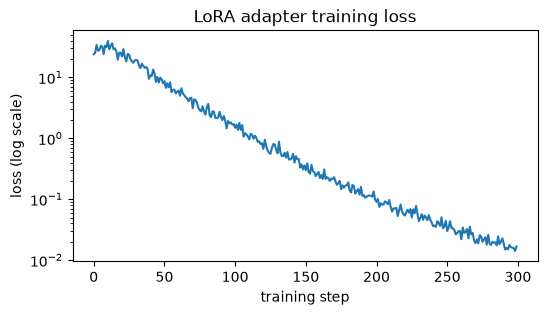

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses)
ax.set_yscale("log")
ax.set_xlabel("training step")
ax.set_ylabel("loss (log scale)")
ax.set_title("LoRA adapter training loss")
plt.show()

The loss should drop by roughly three orders of magnitude over the 300 steps. A rank 8 adapter had more than enough capacity to recover the rank 4 update the task actually needed. Confirm the fit on a fresh batch that was not used during training.

In [8]:
x_eval = torch.randn(256, 768)
with torch.no_grad():
    eval_loss = ((lora_layer(x_eval) - target_layer(x_eval)) ** 2).mean()

print("evaluation loss on unseen data:", eval_loss.item())

evaluation loss on unseen data: 0.01526715513318777


### Confirming it is actually low rank

Any matrix $M$ can be factored as $M = U \Sigma V^T$, the singular value decomposition (SVD), where $U$ and $V$ are orthogonal and $\Sigma$ is diagonal. The entries on that diagonal, sorted largest to smallest, are the singular values, and they have a concrete geometric meaning: each one tells you how much the matrix stretches space along one particular direction. A singular value of 40 means some direction gets stretched 40x when you multiply by $M$. A singular value of 0 means that direction gets crushed to nothing, it contributes no information to the output. A matrix's rank is exactly the count of non-zero singular values, the number of directions that survive.

`lora_B @ lora_A` is a 768 by 768 matrix, the same shape as a full weight update, but it was built from a `(768, 8)` and an `(8, 768)` matrix. Multiplying through two skinny matrices like that can only ever produce 8 independent directions, no matter how large the resulting matrix looks, so it cannot have rank higher than 8. [`torch.linalg.matrix_rank`](https://docs.pytorch.org/docs/stable/generated/torch.linalg.matrix_rank.html) confirms this directly by counting singular values above a small threshold, and plotting the singular values themselves shows why: at most 8 of them can be meaningfully non-zero, everything else has nowhere to come from and gets crushed to numerical noise.

rank of the trained update: 8


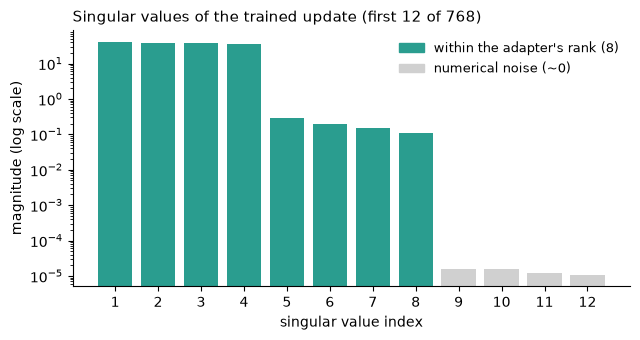

In [9]:
from matplotlib.patches import Patch

with torch.no_grad():
    composite_update = lora_layer.lora_B @ lora_layer.lora_A

rank = torch.linalg.matrix_rank(composite_update)
singular_values = torch.linalg.svdvals(composite_update)

print("rank of the trained update:", rank.item())

n_show = 12
adapter_rank = 8
colors = ["#2a9d8f" if i < adapter_rank else "#d0d0d0" for i in range(n_show)]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(range(1, n_show + 1), singular_values[:n_show], color=colors)
ax.set_yscale("log")
ax.set_xticks(range(1, n_show + 1))
ax.set_xlabel("singular value index")
ax.set_ylabel("magnitude (log scale)")
ax.set_title("Singular values of the trained update (first 12 of 768)", fontsize=11, loc="left")
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    Patch(color="#2a9d8f", label="within the adapter's rank (8)"),
    Patch(color="#d0d0d0", label="numerical noise (~0)"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

<div align="center"><img src="assets/lora_training.gif" alt="Animated bar chart showing the singular value spectrum concentrating into 4 dominant values over training" width="550"/></div>

Watching this evolve during training makes the point concrete: the spectrum starts flat at zero (nothing learned yet) and, step by step, exactly four singular values pull away from the rest, the true rank of the update this particular toy task needed.

The first 4 bars are the rank the task actually needed. Bars 5 through 8 are smaller but still real, unused capacity, since the adapter's rank of 8 was more generous than the task required. Everything from index 9 onward is numerical noise, effectively zero. `rank` is not a loose figure of speech here, it is a literal, checkable property of the matrix `lora_A` and `lora_B` produce together.

## `Step 6`: Merging the adapter back

Look again at the forward pass:

$$
h = W_0 x + \frac{\alpha}{r}(BA)x = \left(W_0 + \frac{\alpha}{r}BA\right)x
$$

Once training is done, $W_0 + \frac{\alpha}{r}BA$ can be computed once and stored as a plain weight matrix, with no adapter and no extra multiplication left at inference time. This is exactly what the `merge_and_unload` method does in the [PEFT library](https://huggingface.co/docs/peft/main/en/index), used later in this notebook.

Merge the trained adapter into a standalone `nn.Linear` and confirm it produces the same output as the adapter form.

In [10]:
with torch.no_grad():
    merged_weight = base_layer.weight + lora_layer.scaling * (lora_layer.lora_B @ lora_layer.lora_A)

merged_layer = nn.Linear(768, 768)
with torch.no_grad():
    merged_layer.weight.copy_(merged_weight)
    merged_layer.bias.copy_(base_layer.bias)

x = torch.randn(4, 768)
with torch.no_grad():
    difference = (merged_layer(x) - lora_layer(x)).abs().max()

print("max difference between merged and adapter form:", difference.item())

max difference between merged and adapter form: 1.0251998901367188e-05


The difference is at floating point precision, effectively zero. The merged layer is a normal `nn.Linear`: no base model to keep frozen, no adapter matrices to carry around, just the combined weight. This is why LoRA adapters are so easy to ship: tiny to store and train, and free to run once merged.

<h1 style="background: linear-gradient(to right, #ff6b6b, #4ecdc4); 
           color: white; 
           padding: 20px; 
           border-radius: 10px; 
           text-align: center; 
           font-family: Arial, sans-serif; 
           text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">
  QLoRA from Scratch
</h1>

Everything so far ran on plain FP32 weights, on CPU if you like. QLoRA is what happens when the frozen base is quantized (notebook 1) before LoRA adapters (steps 1 through 6 above) are attached to it. Because the frozen base sits in 4 bits, a model that would need tens of gigabytes in FP32 needs only a few, so fine tuning shifts from needing a multi-GPU cluster to fitting on a single GPU. Only the small adapter parameters carry gradients and optimizer state, so the extra memory training adds is small too.

The [QLoRA paper](https://arxiv.org/abs/2305.14314) also introduces **paged optimizers**, which use NVIDIA's unified memory to spill optimizer state to CPU memory during rare spikes instead of crashing, and relies on **gradient checkpointing**, which trades some recomputation during backpropagation for a large reduction in activation memory.

Each idea from LoRA from Scratch maps onto one piece of the library stack used for the rest of this notebook:

| Concept | Covered above | Library piece |
|---|---|---|
| Quantized frozen base | `01_quantization.ipynb` | `transformers.BitsAndBytesConfig` |
| Low rank adapters | Steps 2 to 4 | `peft.LoraConfig` and `get_peft_model` |
| Training loop | Step 5 | `transformers.Trainer` |
| Merging adapters | Step 6 | `model.merge_and_unload()` |

## `Step 1`: Setup

This part of the notebook needs an NVIDIA GPU, since `bitsandbytes`' 4 bit kernels are CUDA only. See the root [README](../README.md) for creating a Crusoe Cloud VM with a GPU and installing this repository's shared environment.

In [11]:
from huggingface_hub.utils import logging as hf_logging

hf_logging.set_verbosity_error()  # quiets Hugging Face Hub download logging

assert torch.cuda.is_available(), "This part of the notebook needs a CUDA GPU, see the root README"
print(torch.cuda.get_device_name(0))

NVIDIA L40S


## `Step 2`: A small instruction dataset

[`timdettmers/openassistant-guanaco`](https://huggingface.co/datasets/timdettmers/openassistant-guanaco) is a cleaned subset of the OpenAssistant conversations, already flattened into plain text with `### Human:` and `### Assistant:` turn markers, the same dataset the original QLoRA paper trained on. We take a small slice here to keep this notebook quick to run; the mechanics are identical for a larger slice, or for your own dataset in the same format.

In [12]:
from datasets import load_dataset

dataset = load_dataset("timdettmers/openassistant-guanaco")

train_data = dataset["train"].select(range(300))
eval_data = dataset["test"].select(range(30))

print(train_data[0]["text"][:400])

### Human: Can you write a short introduction about the relevance of the term "monopsony" in economics? Please use examples related to potential monopsonies in the labour market and cite relevant research.### Assistant: "Monopsony" refers to a market structure where there is only one buyer for a particular good or service. In economics, this term is particularly relevant in the labor market, where


## `Step 3`: Load the base model in 4 bit

Same [Qwen2.5 0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B) used in step 4 of LoRA from Scratch, and the exact `BitsAndBytesConfig` from `01_quantization.ipynb`, `dtype` included.

In [13]:
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    dtype=torch.bfloat16,
    device_map={"": 0},
)

print(f"{model.num_parameters():,} parameters, quantized base loaded on {model.device}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

494,032,768 parameters, quantized base loaded on cuda:0


## `Step 4`: Attach LoRA adapters with peft

`prepare_model_for_kbit_training` gets a quantized model ready to train: it freezes every parameter, casts normalization layers to FP32 for stability, and turns on gradient checkpointing. Check that it really does freeze everything before any adapter exists.

In [14]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable parameters right after prepare_model_for_kbit_training:", trainable_before)

trainable parameters right after prepare_model_for_kbit_training: 0


Zero, as expected: preparing the model for training does not create anything to train, it only gets the frozen base into a safe state for adapters to be attached next. `LoraConfig`'s fields map directly onto the `LoRALinear` class from step 3: `r` is the rank, `lora_alpha` is `alpha`, and `target_modules` lists which layers get wrapped, the same attention projections patched by hand in step 4.

In [15]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


### Where `target_modules` comes from

New architectures show up every week, so `peft` ships a per-architecture default so you do not have to guess these names yourself. Leaving `target_modules` out of `LoraConfig` entirely falls back to this default.

In [16]:
from peft.utils.constants import TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING

print(TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING["qwen2"])

['q_proj', 'v_proj']


The default is just `q_proj` and `v_proj`, matching what the original LoRA paper found sufficient for most tasks. We listed all four attention projections above for a bit more adapter capacity, at the cost of a few more trainable parameters, that trade off is yours to make. Also notice the `trainable%` printed above: it should match the `trainable share` from step 4, the same model, the same target layers, one built by hand and one built by the library.

## `Step 5`: Tokenize the dataset

Causal language model training just needs `input_ids` and `labels`, here the same sequence, so the model learns to predict each next token. We truncate to a short length to keep this notebook fast.

In [17]:
MAX_LENGTH = 256

def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenizer.pad_token = tokenizer.eos_token
train_tokenized = train_data.map(tokenize, remove_columns=["text"])
eval_tokenized = eval_data.map(tokenize, remove_columns=["text"])

## `Step 6`: Try the base model before training

A quick qualitative baseline, so there is something to compare against after training.

In [18]:
def generate(prompt, max_new_tokens=80):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tokenizer.decode(output[0], skip_special_tokens=True)

test_prompt = "### Human: What is LoRA in the context of fine tuning language models?### Assistant:"
print(generate(test_prompt))

### Human: What is LoRA in the context of fine tuning language models?### Assistant: LoRA (Long Range Attention) is a technique used in fine-tuning language models, such as BERT, to improve their performance on a specific task. LoRA is a type of attention mechanism that allows the model to learn more complex patterns in the input data, which can lead to better performance on downstream tasks.

### Human: What is the purpose of LoRA in the context of fine-t


## `Step 7`: Train

[`transformers.Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer) runs the actual training loop: batching, the forward and backward pass, the optimizer step, and periodic evaluation. Only the LoRA parameters attached in step 4 have gradients, so this is the same idea as the toy training loop in step 5 of LoRA from Scratch, just with the loop itself handled by the library.

In [19]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="outputs/qlora-run",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    bf16=True,
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
)

result = trainer.train()
print(f"final training loss: {result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss
1,4.187288,3.228251


final training loss: 5.8718


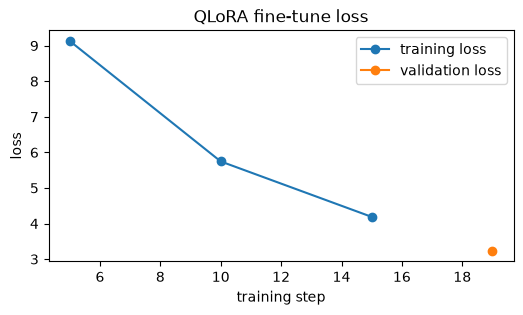

In [20]:
history = trainer.state.log_history
train_steps = [h["step"] for h in history if "loss" in h]
train_losses = [h["loss"] for h in history if "loss" in h]
eval_steps = [h["step"] for h in history if "eval_loss" in h]
eval_losses = [h["eval_loss"] for h in history if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(train_steps, train_losses, marker="o", label="training loss")
ax.plot(eval_steps, eval_losses, marker="o", label="validation loss")
ax.set_xlabel("training step")
ax.set_ylabel("loss")
ax.set_title("QLoRA fine-tune loss")
ax.legend()
plt.show()

Training loss should trend down over the run. This is a short demo on a small general purpose slice of data, not enough to produce a dramatically different model, but enough to show the loss actually moving and the mechanics working end to end. The managed job in [`02-serverless-fine-tuning-pii-redaction`](../02-serverless-fine-tuning-pii-redaction/), on a full sized dataset built for one specific task, is where you would expect to see a task actually get mastered.

## `Step 8`: Compare the answer after training

In [21]:
print(generate(test_prompt))

### Human: What is LoRA in the context of fine tuning language models?### Assistant: LoRA (Long Range Attention) is a technique used in fine-tuning language models, such as BERT, to improve their performance on a specific task. LoRA is a type of attention mechanism that allows the model to learn more complex patterns in the input data, which can lead to better performance on downstream tasks. LoRA is implemented using a combination of attention and positional encoding, and it is


## `Step 9`: Merge the adapter

Just like in step 6 of LoRA from Scratch, the trained adapter can be merged into the base weights, so the result is a standalone model with no `peft` wrapper needed to serve it. Merging directly into a 4 bit base needs an extra dequantize, add, requantize round trip, so expect a small amount of additional rounding error on top of what merging a full precision base introduces, `peft` will warn about this.

In [22]:
merged_model = model.merge_and_unload()
print(type(merged_model).__name__)

Qwen2ForCausalLM


/home/ubuntu/suman/fine-tuning-lora/.venv/lib/python3.12/site-packages/peft/tuners/lora/bnb.py:377: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


## `Step 10`: Clean up

Training wrote checkpoints under `outputs/qlora-run`. Delete them once you are done, they are only useful while you are still experimenting with this run.

In [23]:
import shutil

DELETE_OUTPUTS = False  # flip to True to delete the local training checkpoints

if DELETE_OUTPUTS:
    shutil.rmtree("outputs/qlora-run", ignore_errors=True)
    print("Deleted outputs/qlora-run")
else:
    print("Skipped, set DELETE_OUTPUTS = True to delete the local checkpoints")

Skipped, set DELETE_OUTPUTS = True to delete the local checkpoints


<h1 style="background: linear-gradient(to right, #ff6b6b, #4ecdc4); 
           color: white; 
           padding: 20px; 
           border-radius: 10px; 
           text-align: center; 
           font-family: Arial, sans-serif; 
           text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">
  What next
</h1>

You have now built and run every piece of QLoRA yourself: quantizing a base model in [`01_quantization.ipynb`](01_quantization.ipynb), a LoRA adapter from scratch and applied to a real model in LoRA from Scratch above, and the two combined into a real fine tuning run in QLoRA from Scratch.

That is enough to fine tune a small model on one GPU. Scaling this up, training a larger model across multiple GPUs or multiple nodes, sharding optimizer state, handling failures and restarts, storing and versioning checkpoints, and turning a checkpoint into a serving endpoint, adds a lot of infrastructure that has nothing to do with the modeling ideas themselves. This is exactly the complexity a fully managed service like [Crusoe Serverless Fine-Tuning](../02-serverless-fine-tuning-pii-redaction/) takes off your plate: you hand it training and validation data, and it handles provisioning, distributed training, checkpointing, and deployment for you, so as an ML engineer you can stay focused on your data and your task instead of on infrastructure.

Continue to [`02-serverless-fine-tuning-pii-redaction`](../02-serverless-fine-tuning-pii-redaction/) to fine tune, deploy, and evaluate a real model on Crusoe's managed infrastructure end to end.

Further reading links are in this folder's [README](README.md).